In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
from torchvision.models.mobilenetv3 import MobileNet_V3_Small_Weights
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, classification_report
import os

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [12]:
# Data transforms (MobileNetV3 uses 224x224 input)
train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load full dataset (update path)
dataset_path = '/home/rifat-cou/Documents/Project/augmented_dataset'  # Folder with class subfolders
full_dataset = datasets.ImageFolder(dataset_path, transform=train_transform)

# Split train/val (80/20)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# Apply val transform
val_dataset.dataset.transform = val_transform

# Loaders (batch 32; fits 6GB VRAM, ~2-3GB usage)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4)

# Classes
class_names = full_dataset.classes
print(f"Classes: {class_names}")
print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}")

Classes: ['Chikenpox', 'Cowpox', 'Measles', 'MonkeyPox', 'Normal']
Train: 12532, Val: 3134


In [13]:
# Load MobileNetV3 Small
model = models.mobilenet_v3_small(weights=MobileNet_V3_Small_Weights.DEFAULT)

# Freeze except classifier
for param in model.parameters():
    param.requires_grad = False

# Modify classifier
num_features = model.classifier[3].in_features  # Last Linear layer
model.classifier[3] = nn.Linear(num_features, 5)

# To GPU
model = model.to(device)

# Summary (optional)
print(model)

MobileNetV3(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): SqueezeExcitation(
          (avgpool): AdaptiveAvgPool2d(output_size=1)
          (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
          (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
          (activation): ReLU()
          (scale_activation): Hardsigmoid()
        )
        (2): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(1, 1), 

In [14]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=0.001)  # Classifier only first
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)

Epoch 1/100 - Train Loss: 0.8221, Acc: 0.7031 | Val Loss: 0.6196, Acc: 0.7805
Epoch 2/100 - Train Loss: 0.6404, Acc: 0.7649 | Val Loss: 0.5737, Acc: 0.7923
Epoch 3/100 - Train Loss: 0.5957, Acc: 0.7804 | Val Loss: 0.5483, Acc: 0.7983
Epoch 4/100 - Train Loss: 0.5832, Acc: 0.7834 | Val Loss: 0.5345, Acc: 0.8015
Epoch 5/100 - Train Loss: 0.5654, Acc: 0.7924 | Val Loss: 0.5241, Acc: 0.8041
Epoch 6/100 - Train Loss: 0.5645, Acc: 0.7926 | Val Loss: 0.5121, Acc: 0.8066
Epoch 7/100 - Train Loss: 0.5480, Acc: 0.7941 | Val Loss: 0.5127, Acc: 0.8041
Epoch 8/100 - Train Loss: 0.5413, Acc: 0.7968 | Val Loss: 0.5110, Acc: 0.8073
Epoch 9/100 - Train Loss: 0.5472, Acc: 0.7941 | Val Loss: 0.5196, Acc: 0.8028
Epoch 10/100 - Train Loss: 0.5451, Acc: 0.7927 | Val Loss: 0.5143, Acc: 0.8073
Epoch 11/100 - Train Loss: 0.5484, Acc: 0.7933 | Val Loss: 0.5061, Acc: 0.8108
Epoch 12/100 - Train Loss: 0.5352, Acc: 0.7960 | Val Loss: 0.5087, Acc: 0.8133
Epoch 13/100 - Train Loss: 0.5436, Acc: 0.7970 | Val Loss: 0.

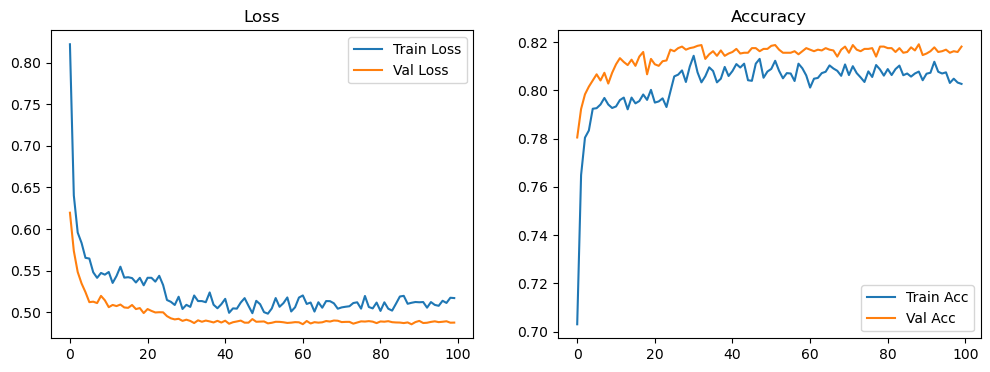

In [15]:
num_epochs = 100
train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(num_epochs):
    # Train
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    train_loss = running_loss / len(train_loader)
    train_acc = correct / total
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    
    # Validate
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    val_loss /= len(val_loader)
    val_acc = correct / total
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    
    scheduler.step(val_loss)
    
    print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")

# Plots
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.legend()
plt.title('Loss')
plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs, label='Val Acc')
plt.legend()
plt.title('Accuracy')
plt.show()

In [16]:
# Eval
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print(classification_report(all_labels, all_preds, target_names=class_names))
print(f"Accuracy: {accuracy_score(all_labels, all_preds):.4f}")

model_path = '/home/rifat-cou/Documents/Project/Models'
MobileNetV3 = os.path.join(model_path, 'MovileNetV3_1')
os.makedirs(MobileNetV3, exist_ok=True) 
# Save
torch.save(model.state_dict(), os.path.join(MobileNetV3,'mobilenet_v3_skin_lesion.pth'))

              precision    recall  f1-score   support

   Chikenpox       0.74      0.68      0.71       608
      Cowpox       0.92      0.93      0.93       595
     Measles       0.85      0.86      0.86       611
   MonkeyPox       0.74      0.70      0.72       653
      Normal       0.83      0.92      0.87       667

    accuracy                           0.82      3134
   macro avg       0.82      0.82      0.82      3134
weighted avg       0.82      0.82      0.82      3134

Accuracy: 0.8181
